In [15]:
# look into what are nulls
# look at the differnt VendoreID informations
# look at the unique PULocationID

In [16]:
import pandas as pd

In [17]:
df = pd.read_parquet('../data/yellow_tripdata_2025-01.parquet')

In [18]:
df.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee
0,1,2025-01-01 00:18:38,2025-01-01 00:26:59,1.0,1.60,1.0,N,229,237,1,10.0,3.5,0.5,3.00,0.0,1.0,18.00,2.5,0.0,0.0
1,1,2025-01-01 00:32:40,2025-01-01 00:35:13,1.0,0.50,1.0,N,236,237,1,5.1,3.5,0.5,2.02,0.0,1.0,12.12,2.5,0.0,0.0
2,1,2025-01-01 00:44:04,2025-01-01 00:46:01,1.0,0.60,1.0,N,141,141,1,5.1,3.5,0.5,2.00,0.0,1.0,12.10,2.5,0.0,0.0
3,2,2025-01-01 00:14:27,2025-01-01 00:20:01,3.0,0.52,1.0,N,244,244,2,7.2,1.0,0.5,0.00,0.0,1.0,9.70,0.0,0.0,0.0
4,2,2025-01-01 00:21:34,2025-01-01 00:25:06,3.0,0.66,1.0,N,244,116,2,5.8,1.0,0.5,0.00,0.0,1.0,8.30,0.0,0.0,0.0


In [19]:
# Need to colapes the data to an hourly rate by pick up location

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3475226 entries, 0 to 3475225
Data columns (total 20 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   VendorID               int32         
 1   tpep_pickup_datetime   datetime64[us]
 2   tpep_dropoff_datetime  datetime64[us]
 3   passenger_count        float64       
 4   trip_distance          float64       
 5   RatecodeID             float64       
 6   store_and_fwd_flag     object        
 7   PULocationID           int32         
 8   DOLocationID           int32         
 9   payment_type           int64         
 10  fare_amount            float64       
 11  extra                  float64       
 12  mta_tax                float64       
 13  tip_amount             float64       
 14  tolls_amount           float64       
 15  improvement_surcharge  float64       
 16  total_amount           float64       
 17  congestion_surcharge   float64       
 18  Airport_fee           

In [21]:
df.describe()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee
count,3.475226e+06,3475226,3475226,2.935077e+06,3.475226e+06,2.935077e+06,3.475226e+06,3.475226e+06,3.475226e+06,3.475226e+06,3.475226e+06,3.475226e+06,3.475226e+06,3.475226e+06,3.475226e+06,3.475226e+06,2.935077e+06,2.935077e+06,3.475226e+06
mean,1.785428e+00,2025-01-17 11:02:55.910964,2025-01-17 11:17:56.997901,1.297859e+00,5.855126e+00,2.482535e+00,1.651916e+02,1.641252e+02,1.036623e+00,1.708180e+01,1.317737e+00,4.780991e-01,2.959813e+00,4.493081e-01,9.547946e-01,2.561129e+01,2.225237e+00,1.239111e-01,4.834093e-01
min,1.000000e+00,2024-12-31 20:47:55,2024-12-18 07:52:40,0.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00,-9.000000e+02,-7.500000e+00,-5.000000e-01,-8.600000e+01,-1.269400e+02,-1.000000e+00,-9.010000e+02,-2.500000e+00,-1.750000e+00,-7.500000e-01
25%,2.000000e+00,2025-01-10 07:59:01,2025-01-10 08:15:29.500000,1.000000e+00,9.800000e-01,1.000000e+00,1.320000e+02,1.130000e+02,1.000000e+00,8.600000e+00,0.000000e+00,5.000000e-01,0.000000e+00,0.000000e+00,1.000000e+00,1.520000e+01,2.500000e+00,0.000000e+00,0.000000e+00
50%,2.000000e+00,2025-01-17 15:41:33,2025-01-17 15:59:34,1.000000e+00,1.670000e+00,1.000000e+00,1.620000e+02,1.620000e+02,1.000000e+00,1.211000e+01,0.000000e+00,5.000000e-01,2.450000e+00,0.000000e+00,1.000000e+00,1.995000e+01,2.500000e+00,0.000000e+00,7.500000e-01
75%,2.000000e+00,2025-01-24 19:34:06,2025-01-24 19:48:31,1.000000e+00,3.100000e+00,1.000000e+00,2.340000e+02,2.340000e+02,1.000000e+00,1.950000e+01,2.500000e+00,5.000000e-01,3.930000e+00,0.000000e+00,1.000000e+00,2.778000e+01,2.500000e+00,0.000000e+00,7.500000e-01
max,7.000000e+00,2025-02-01 00:00:44,2025-02-01 23:44:11,9.000000e+00,2.764236e+05,9.900000e+01,2.650000e+02,2.650000e+02,5.000000e+00,8.633721e+05,1.500000e+01,1.050000e+01,4.000000e+02,1.709400e+02,1.000000e+00,8.633804e+05,2.500000e+00,6.750000e+00,7.500000e-01
std,4.263282e-01,NaN,NaN,7.507503e-01,5.646016e+02,1.163277e+01,6.452948e+01,6.940169e+01,7.013334e-01,4.634729e+02,1.861509e+00,1.374623e-01,3.779681e+00,2.002582e+00,2.781938e-01,4.636585e+02,9.039932e-01,4.725090e-01,3.619307e-01


In [22]:
df[df['payment_type'] == 3]


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee
445,1,2025-01-01 00:13:17,2025-01-01 00:26:37,2.0,1.60,1.0,N,237,229,3,12.1,3.5,0.5,0.0,0.00,1.0,17.10,2.5,0.0,0.00
707,1,2025-01-01 00:45:41,2025-01-01 01:04:59,0.0,4.70,1.0,N,261,170,3,22.6,3.5,0.5,0.0,0.00,1.0,27.60,2.5,0.0,0.00
822,2,2025-01-01 00:49:36,2025-01-01 02:11:46,4.0,24.70,1.0,N,68,82,3,-111.5,-1.0,-0.5,0.0,-6.94,-1.0,-123.44,-2.5,0.0,0.00
823,2,2025-01-01 00:49:36,2025-01-01 02:11:46,4.0,24.70,1.0,N,68,82,3,111.5,1.0,0.5,0.0,6.94,1.0,123.44,2.5,0.0,0.00
835,1,2025-01-01 00:46:24,2025-01-01 00:58:36,2.0,1.70,1.0,N,43,238,3,10.7,3.5,0.5,0.0,0.00,1.0,15.70,2.5,0.0,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2934929,2,2025-01-31 23:58:48,2025-02-01 00:08:12,1.0,1.94,1.0,N,48,68,3,12.1,1.0,0.5,0.0,0.00,1.0,17.85,2.5,0.0,0.75
2934960,2,2025-01-31 23:41:22,2025-01-31 23:43:05,1.0,0.04,1.0,N,263,263,3,-3.7,-1.0,-0.5,0.0,0.00,-1.0,-8.70,-2.5,0.0,0.00
2934961,2,2025-01-31 23:41:22,2025-01-31 23:43:05,1.0,0.04,1.0,N,263,263,3,3.7,1.0,0.5,0.0,0.00,1.0,8.70,2.5,0.0,0.00
2935015,2,2025-01-31 23:14:54,2025-01-31 23:23:48,2.0,1.08,1.0,N,114,158,3,-9.3,-1.0,-0.5,0.0,0.00,-1.0,-15.05,-2.5,0.0,-0.75


In [23]:
df.isnull().sum()


VendorID                      0
tpep_pickup_datetime          0
tpep_dropoff_datetime         0
passenger_count          540149
trip_distance                 0
RatecodeID               540149
store_and_fwd_flag       540149
PULocationID                  0
DOLocationID                  0
payment_type                  0
fare_amount                   0
extra                         0
mta_tax                       0
tip_amount                    0
tolls_amount                  0
improvement_surcharge         0
total_amount                  0
congestion_surcharge     540149
Airport_fee              540149
cbd_congestion_fee            0
dtype: int64

In [24]:
# Check invalid or unexpected categorical values
fields_to_check = ["payment_type", "RatecodeID", "VendorID"]

expected_values = {
    "payment_type": {0, 1, 2, 3, 4, 5, 6},
    "RatecodeID": {1, 2, 3, 4, 5, 6, 99},
    "VendorID": {1, 2, 6, 7},
}

for col in fields_to_check:
    print(f"\n=== {col} ===")
    s = df[col]

    print(f"dtype: {s.dtype}")
    print(f"nulls: {s.isna().sum():,}")

    if s.dropna().empty:
        print("All values are null.")
        continue

    print(f"min: {s.min()}")
    print(f"max: {s.max()}")
    print(f"n_unique: {s.nunique(dropna=True):,}")

    top_counts = s.value_counts(dropna=False).head(10)
    print("top frequencies:")
    print(top_counts)

    if col in expected_values:
        observed = set(s.dropna().astype(int).unique())
        unexpected = sorted(observed - expected_values[col])
        missing_expected = sorted(expected_values[col] - observed)

        print(f"unexpected codes: {unexpected if unexpected else 'None'}")
        print(f"expected but not present: {missing_expected if missing_expected else 'None'}")


=== payment_type ===
dtype: int64
nulls: 0
min: 0
max: 5
n_unique: 6
top frequencies:
payment_type
1    2444393
0     540149
2     390429
4      76481
3      23773
5          1
Name: count, dtype: int64
unexpected codes: None
expected but not present: [6]

=== RatecodeID ===
dtype: float64
nulls: 540,149
min: 1.0
max: 99.0
n_unique: 7
top frequencies:
RatecodeID
1.0     2756472
NaN      540149
2.0       94420
99.0      41963
5.0       26501
3.0        8622
4.0        7092
6.0           7
Name: count, dtype: int64
unexpected codes: None
expected but not present: None

=== VendorID ===
dtype: int32
nulls: 0
min: 1
max: 7
n_unique: 4
top frequencies:
VendorID
2    2719860
1     753671
7       1206
6        489
Name: count, dtype: int64
unexpected codes: None
expected but not present: None


In [25]:
# Data quality checks: negative/impossible amounts and suspicious trip values
amount_cols = [
    "fare_amount",
    "extra",
    "mta_tax",
    "tip_amount",
    "tolls_amount",
    "improvement_surcharge",
    "congestion_surcharge",
    "Airport_fee",
    "cbd_congestion_fee",
]

# 1) Rows with negative values in fee/fare columns
negative_amount_mask = (df[amount_cols] < 0).any(axis=1)
negative_amount_rows = df.loc[negative_amount_mask].copy()

print(f"Rows with at least one negative fare/fee component: {negative_amount_mask.sum():,}")
if not negative_amount_rows.empty:
    display(negative_amount_rows[amount_cols + ["total_amount", "payment_type"]].head(10))

# 2) Compare total_amount to sum of components
component_sum = df[amount_cols].sum(axis=1)
total_mismatch = (df["total_amount"] - component_sum).abs() > 0.01
mismatch_rows = df.loc[total_mismatch].copy()

print(f"Rows where total_amount != component sum (tolerance 0.01): {total_mismatch.sum():,}")
if not mismatch_rows.empty:
    preview_cols = amount_cols + ["total_amount", "payment_type"]
    mismatch_preview = mismatch_rows[preview_cols].head(10).copy()
    mismatch_preview["component_sum"] = component_sum.loc[mismatch_preview.index]
    mismatch_preview["abs_diff"] = (mismatch_preview["total_amount"] - mismatch_preview["component_sum"]).abs()
    display(mismatch_preview)

# 3) Zero/suspicious trip values
suspicious_trip_mask = (
    (df["trip_distance"] == 0)
    | (df["trip_distance"] > 100)
    | (df["passenger_count"] <= 0)
    | (df["passenger_count"] > 8)
)
suspicious_trip_rows = df.loc[suspicious_trip_mask].copy()

print(f"Rows with zero or suspicious trip values: {suspicious_trip_mask.sum():,}")
if not suspicious_trip_rows.empty:
    display(
        suspicious_trip_rows[
            [
                "tpep_pickup_datetime",
                "tpep_dropoff_datetime",
                "passenger_count",
                "trip_distance",
                "fare_amount",
                "total_amount",
                "PULocationID",
                "DOLocationID",
            ]
        ].head(10)
    )

Rows with at least one negative fare/fee component: 144,833


,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,congestion_surcharge,Airport_fee,cbd_congestion_fee,total_amount,payment_type
17,-7.2,-1.0,-0.5,3.66,0.0,-1.0,-2.5,0.0,0.0,-8.54,2
22,-6.5,-1.0,-0.5,0.00,0.0,-1.0,-2.5,0.0,0.0,-11.50,4
104,-16.3,-1.0,-0.5,0.00,0.0,-1.0,-2.5,0.0,0.0,-21.30,4
149,-12.1,-1.0,-0.5,0.00,0.0,-1.0,-2.5,0.0,0.0,-17.10,2
202,-7.2,-1.0,-0.5,0.00,0.0,-1.0,-2.5,0.0,0.0,-12.20,4
212,-14.2,-1.0,-0.5,0.00,0.0,-1.0,-2.5,0.0,0.0,-19.20,4
364,-3.0,-1.0,-0.5,0.00,0.0,-1.0,0.0,0.0,0.0,-5.50,4
400,-6.5,-1.0,-0.5,0.00,0.0,-1.0,-2.5,0.0,0.0,-11.50,2
492,-24.0,-1.0,-0.5,0.00,0.0,-1.0,-2.5,0.0,0.0,-29.00,2
640,-6.5,-1.0,-0.5,0.00,0.0,-1.0,-2.5,0.0,0.0,-11.50,2


Rows where total_amount != component sum (tolerance 0.01): 1,111,807


,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,congestion_surcharge,Airport_fee,cbd_congestion_fee,total_amount,payment_type,component_sum,abs_diff
0,10.0,3.5,0.5,3.00,0.0,1.0,2.5,0.0,0.0,18.00,1,20.50,2.5
1,5.1,3.5,0.5,2.02,0.0,1.0,2.5,0.0,0.0,12.12,1,14.62,2.5
2,5.1,3.5,0.5,2.00,0.0,1.0,2.5,0.0,0.0,12.10,1,14.60,2.5
6,4.4,3.5,0.5,2.35,0.0,1.0,2.5,0.0,0.0,11.75,1,14.25,2.5
7,12.1,3.5,0.5,2.00,0.0,1.0,2.5,0.0,0.0,19.10,1,21.60,2.5
8,19.1,3.5,0.5,3.00,0.0,1.0,2.5,0.0,0.0,27.10,1,29.60,2.5
13,7.9,3.5,0.5,0.00,0.0,1.0,2.5,0.0,0.0,12.90,2,15.40,2.5
14,26.1,3.5,0.5,7.80,0.0,1.0,2.5,0.0,0.0,38.90,1,41.40,2.5
15,17.7,3.5,0.5,0.00,0.0,1.0,2.5,0.0,0.0,22.70,2,25.20,2.5
16,16.3,3.5,0.5,4.25,0.0,1.0,2.5,0.0,0.0,25.55,1,28.05,2.5


Rows with zero or suspicious trip values: 114,713


,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,fare_amount,total_amount,PULocationID,DOLocationID
6,2025-01-01 00:14:47,2025-01-01 00:16:15,0.0,0.40,4.40,11.75,170,170
7,2025-01-01 00:39:27,2025-01-01 00:51:51,0.0,1.60,12.10,19.10,234,148
8,2025-01-01 00:53:43,2025-01-01 01:13:23,0.0,2.80,19.10,27.10,148,170
92,2025-01-01 00:49:48,2025-01-01 00:49:48,1.0,0.00,20.06,20.06,87,264
94,2025-01-01 00:11:27,2025-01-01 00:16:58,0.0,0.70,7.20,12.20,144,211
95,2025-01-01 00:19:30,2025-01-01 00:27:25,0.0,1.00,9.30,17.15,211,158
96,2025-01-01 00:33:13,2025-01-01 00:40:08,0.0,1.20,8.60,14.60,158,68
97,2025-01-01 00:45:05,2025-01-01 01:20:32,0.0,1.80,28.20,41.50,68,50
98,2025-01-01 00:04:29,2025-01-01 00:55:58,9.0,31.97,90.00,111.32,132,265
173,2025-01-01 00:01:44,2025-01-01 00:08:38,0.0,0.90,7.90,13.90,113,148


In [26]:
# Data quality checks: timestamp problems + categorical encoding issues

# ------------------------------
# 1) Timestamp checks
# ------------------------------
pickup = df["tpep_pickup_datetime"]
dropoff = df["tpep_dropoff_datetime"]

null_timestamp_mask = pickup.isna() | dropoff.isna()
reversed_timestamp_mask = dropoff < pickup
zero_duration_mask = dropoff == pickup
long_duration_mask = (dropoff - pickup).dt.total_seconds() > 6 * 3600

print("Timestamp checks")
print(f"null pickup/dropoff timestamps: {null_timestamp_mask.sum():,}")
print(f"dropoff earlier than pickup: {reversed_timestamp_mask.sum():,}")
print(f"zero-duration trips: {zero_duration_mask.sum():,}")
print(f"very long trips (> 6 hours): {long_duration_mask.sum():,}")

# Duplicate timestamp pairs by pickup/dropoff/location
dup_trip_time_loc_mask = df.duplicated(
    subset=["tpep_pickup_datetime", "tpep_dropoff_datetime", "PULocationID", "DOLocationID"],
    keep=False,
)
print(f"duplicate pickup/dropoff/location combinations: {dup_trip_time_loc_mask.sum():,}")

if reversed_timestamp_mask.any():
    print("\nSample rows where dropoff < pickup:")
    display(
        df.loc[
            reversed_timestamp_mask,
            [
                "tpep_pickup_datetime",
                "tpep_dropoff_datetime",
                "trip_distance",
                "passenger_count",
                "PULocationID",
                "DOLocationID",
            ],
        ].head(10)
    )



Timestamp checks
null pickup/dropoff timestamps: 0
dropoff earlier than pickup: 124
zero-duration trips: 1,927
very long trips (> 6 hours): 1,203
duplicate pickup/dropoff/location combinations: 105,082

Sample rows where dropoff < pickup:


,tpep_pickup_datetime,tpep_dropoff_datetime,trip_distance,passenger_count,PULocationID,DOLocationID
99620,2025-01-02 12:26:00,2025-01-02 11:29:58,9.00,1.0,88,210
459885,2025-01-06 16:00:00,2025-01-06 15:05:30,3.80,1.0,208,254
1315880,2025-01-15 15:00:00,2025-01-15 14:42:48,1.00,1.0,107,4
2029534,2025-01-23 01:44:59,2024-12-18 07:52:40,3.10,0.0,162,238
2058555,2025-01-23 12:30:00,2025-01-23 11:44:59,3.90,1.0,236,116
2660983,2025-01-29 14:00:00,2025-01-29 13:30:15,1.50,1.0,72,222
2945475,2025-01-01 10:01:27,2025-01-01 10:01:00,19.19,NaN,169,35
2945514,2025-01-01 10:01:53,2025-01-01 10:01:33,12.17,NaN,41,121
2951588,2025-01-02 08:01:41,2025-01-02 08:01:16,14.89,NaN,28,244
2952145,2025-01-02 11:01:37,2025-01-02 11:01:29,12.71,NaN,197,74


In [27]:
# ------------------------------
# 2) Categorical encoding checks
# ------------------------------
print("\nCategorical encoding checks")

store_expected = {"Y", "N"}
store_observed = set(df["store_and_fwd_flag"].dropna().astype(str).str.strip().unique())
store_unexpected = sorted(store_observed - store_expected)
print(f"store_and_fwd_flag unexpected codes: {store_unexpected if store_unexpected else 'None'}")

# NYC TLC taxi zones are typically 1..265 (with some IDs representing unknown/NA zones in lookup data).
valid_zone_min = 1
valid_zone_max = 265

invalid_pu_zone_mask = (~df["PULocationID"].between(valid_zone_min, valid_zone_max)) | df["PULocationID"].isna()
invalid_do_zone_mask = (~df["DOLocationID"].between(valid_zone_min, valid_zone_max)) | df["DOLocationID"].isna()

print(f"invalid PULocationID rows (outside {valid_zone_min}-{valid_zone_max} or null): {invalid_pu_zone_mask.sum():,}")
print(f"invalid DOLocationID rows (outside {valid_zone_min}-{valid_zone_max} or null): {invalid_do_zone_mask.sum():,}")

if invalid_pu_zone_mask.any() or invalid_do_zone_mask.any():
    print("\nSample rows with invalid location IDs:")
    display(
        df.loc[
            invalid_pu_zone_mask | invalid_do_zone_mask,
            [
                "tpep_pickup_datetime",
                "tpep_dropoff_datetime",
                "PULocationID",
                "DOLocationID",
                "store_and_fwd_flag",
            ],
        ].head(10)
    )


Categorical encoding checks
store_and_fwd_flag unexpected codes: None
invalid PULocationID rows (outside 1-265 or null): 0
invalid DOLocationID rows (outside 1-265 or null): 0


In [28]:
# Data quality checks: outliers + duplicate records

# ------------------------------
# 1) Outlier checks (summary stats + percentile + IQR)
# ------------------------------
outlier_cols = [
    "trip_distance",
    "passenger_count",
    "fare_amount",
    "total_amount",
    "tip_amount",
]

summary_stats = df[outlier_cols].describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]).T
print("Outlier-oriented summary statistics")
display(summary_stats)

iqr_rows = []
for col in outlier_cols:
    s = df[col].dropna()
    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    mask = (df[col] < lower) | (df[col] > upper)

    iqr_rows.append(
        {
            "column": col,
            "q1": round(float(q1), 4),
            "q3": round(float(q3), 4),
            "iqr": round(float(iqr), 4),
            "lower_bound": round(float(lower), 4),
            "upper_bound": round(float(upper), 4),
            "iqr_outlier_rows": int(mask.sum()),
            "iqr_outlier_pct": round(float(mask.mean() * 100), 2),
            "p99": round(float(s.quantile(0.99)), 4),
            "max": round(float(s.max()), 4),
        }
    )

iqr_outlier_summary = pd.DataFrame(iqr_rows)
print("IQR outlier summary")
display(iqr_outlier_summary)





Outlier-oriented summary statistics


,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
trip_distance,3475226.0,5.855126,564.601600,0.0,0.0,0.39,0.98,1.67,3.10,11.83,19.50,276423.57
passenger_count,2935077.0,1.297859,0.750750,0.0,1.0,1.00,1.00,1.00,1.00,3.00,5.00,9.00
fare_amount,3475226.0,17.081803,463.472918,-900.0,-10.7,3.70,8.60,12.11,19.50,52.00,72.30,863372.12
total_amount,3475226.0,25.611292,463.658478,-901.0,-15.7,8.75,15.20,19.95,27.78,74.00,102.92,863380.37
tip_amount,3475226.0,2.959813,3.779681,-86.0,0.0,0.00,0.00,2.45,3.93,10.00,17.19,400.00


IQR outlier summary


,column,q1,q3,iqr,lower_bound,upper_bound,iqr_outlier_rows,iqr_outlier_pct,p99,max
0,trip_distance,0.98,3.10,2.12,-2.200,6.280,422436,12.16,19.50,276423.57
1,passenger_count,1.00,1.00,0.00,1.000,1.000,612643,17.63,5.00,9.00
2,fare_amount,8.60,19.50,10.90,-7.750,35.850,381907,10.99,72.30,863372.12
3,total_amount,15.20,27.78,12.58,-3.670,46.650,402661,11.59,102.92,863380.37
4,tip_amount,0.00,3.93,3.93,-5.895,9.825,194129,5.59,17.19,400.00


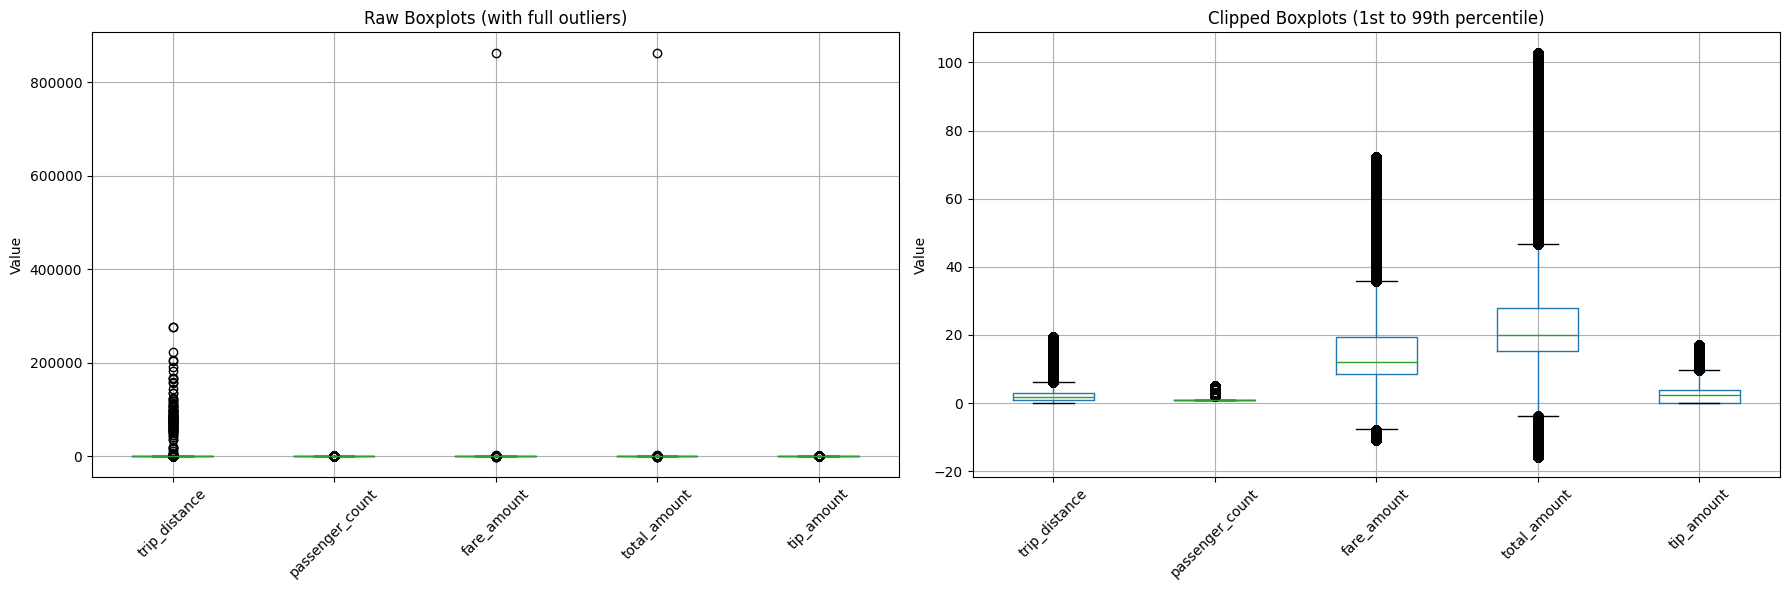

In [29]:
# Boxplots for outlier visualization
import matplotlib.pyplot as plt

# Reuse outlier_cols if it exists; otherwise define a default set.
plot_cols = outlier_cols if "outlier_cols" in globals() else [
    "trip_distance",
    "passenger_count",
    "fare_amount",
    "total_amount",
    "tip_amount",
]

plot_df = df[plot_cols].copy()

# Create a clipped copy (1st to 99th percentile) to improve readability.
clipped_df = plot_df.copy()
for c in plot_cols:
    lo = plot_df[c].quantile(0.01)
    hi = plot_df[c].quantile(0.99)
    clipped_df[c] = plot_df[c].clip(lower=lo, upper=hi)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

plot_df.boxplot(column=plot_cols, ax=axes[0], rot=45)
axes[0].set_title("Raw Boxplots (with full outliers)")
axes[0].set_ylabel("Value")

clipped_df.boxplot(column=plot_cols, ax=axes[1], rot=45)
axes[1].set_title("Clipped Boxplots (1st to 99th percentile)")
axes[1].set_ylabel("Value")

plt.tight_layout()
plt.show()

In [30]:
# ------------------------------
# 2) Duplicate record checks
# ------------------------------
full_dup_count = df.duplicated().sum()
print(f"Exact duplicate rows (all columns): {full_dup_count:,}")

key_cols = [
    "VendorID",
    "tpep_pickup_datetime",
    "tpep_dropoff_datetime",
    "PULocationID",
    "DOLocationID",
    "trip_distance",
    "fare_amount",
    "total_amount",
]

key_dup_mask = df.duplicated(subset=key_cols, keep=False)
key_dup_count = key_dup_mask.sum()
print(f"Duplicate rows on trip key fields: {key_dup_count:,}")

if full_dup_count > 0:
    print("\nSample exact duplicate rows:")
    display(df[df.duplicated(keep=False)].head(10))

Exact duplicate rows (all columns): 0
Duplicate rows on trip key fields: 0


## Assessment Questions

### Dataseet Shape and Coumn meanings

 Dataset shape

3,475,226 rows x 20 columns

 Column meanings

| Column | Meaning |
| --- | --- |
| VendorID | Taxi vendor code |
| tpep_pickup_datetime | Pickup timestamp |
| tpep_dropoff_datetime | Dropoff timestamp |
| passenger_count | Number of passengers reported for the trip |
| trip_distance | Trip distance in miles |
| RatecodeID | Rate type code |
| store_and_fwd_flag | Whether the trip record was stored before forwarding |
| PULocationID | Pickup taxi zone ID |
| DOLocationID | Dropoff taxi zone ID |
| payment_type | Payment method code |
| fare_amount | Metered fare amount before extras and fees |
| extra | Extra charges and surcharges |
| mta_tax | MTA tax |
| tip_amount | Tip amount |
| tolls_amount | Tolls charged |
| improvement_surcharge | TLC improvement surcharge |
| total_amount | Total amount charged |
| congestion_surcharge | Congestion surcharge |
| Airport_fee | Airport fee, when applicable |
| cbd_congestion_fee | CBD congestion pricing fee |



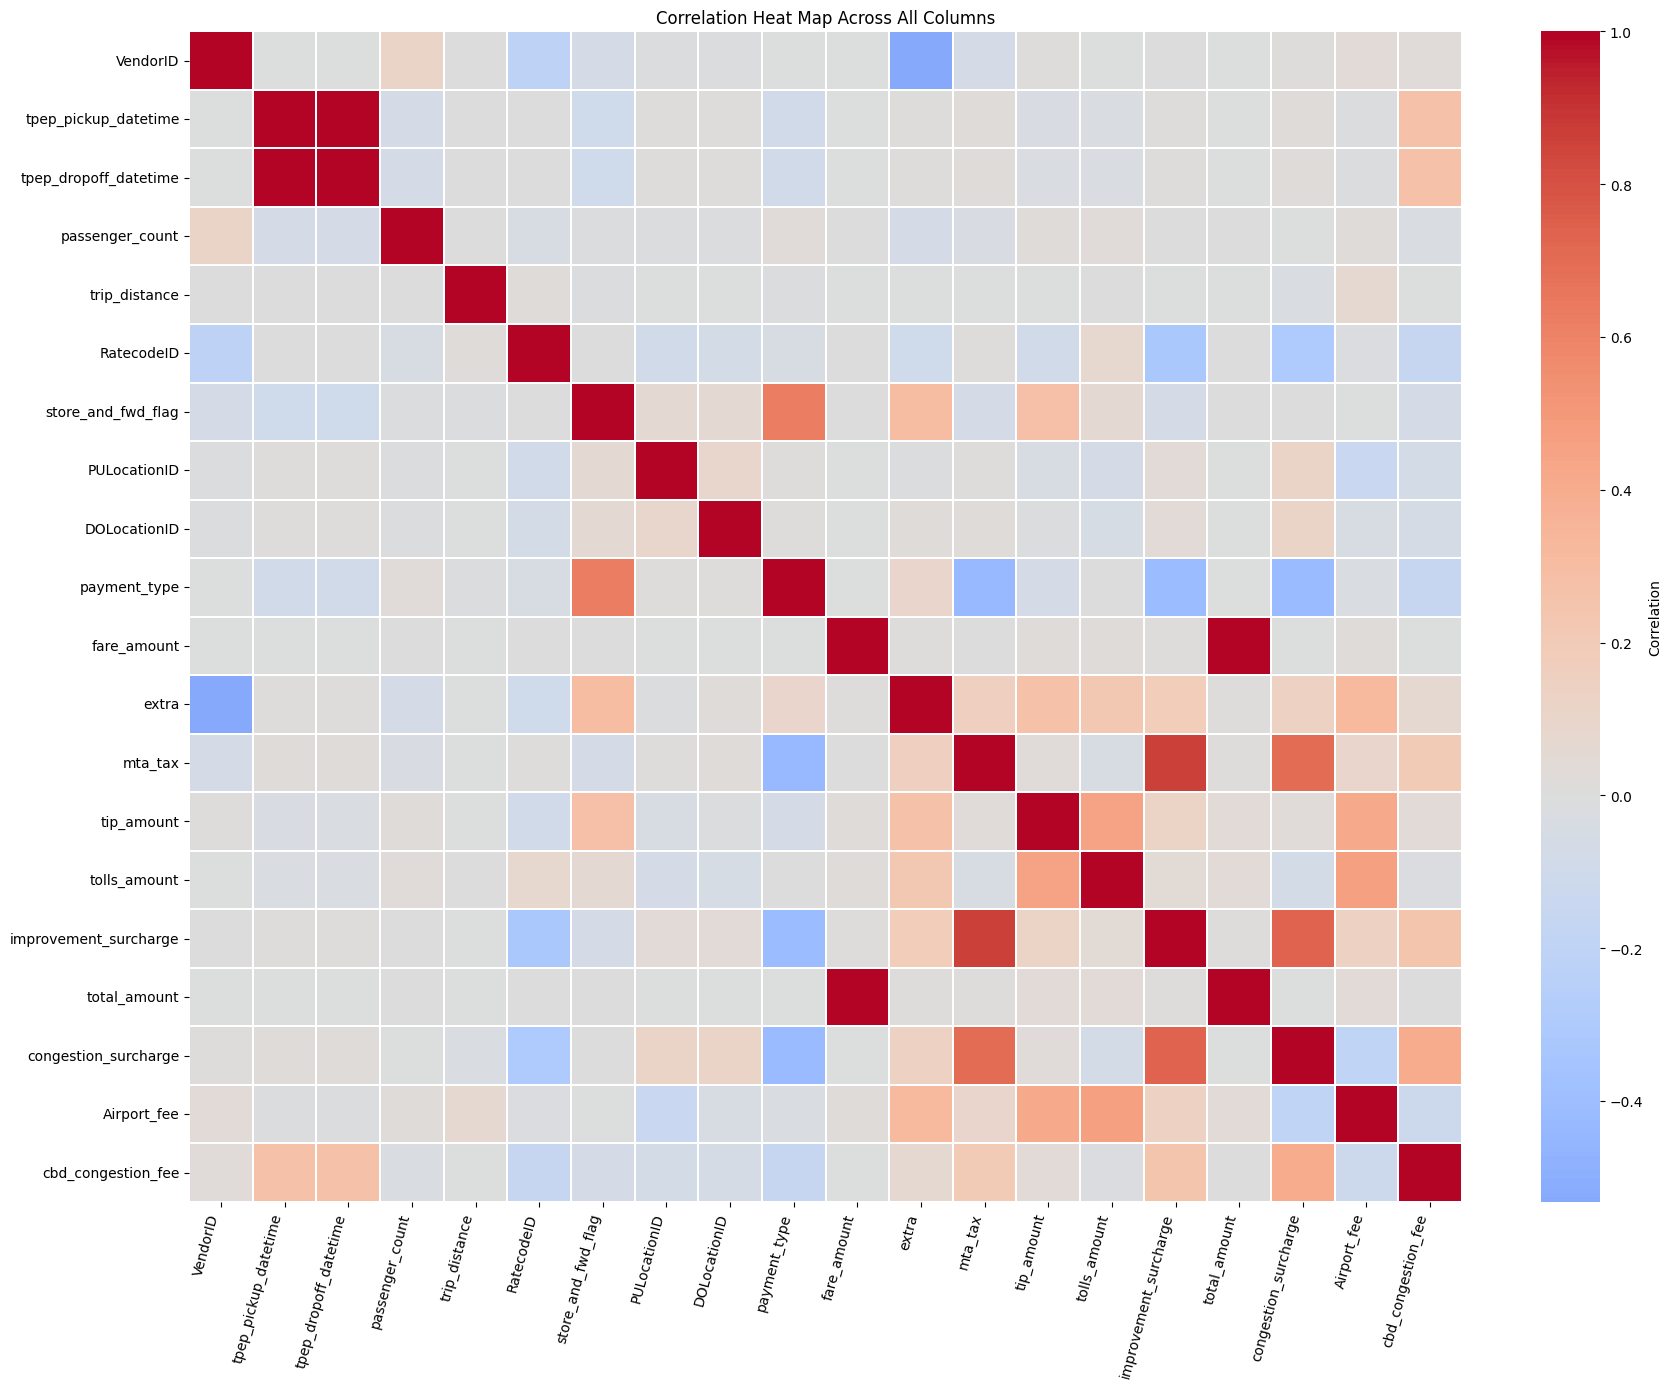

In [32]:
# Heat map comparing all columns (numeric + encoded datetime/categorical)
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

corr_df = df.copy()

# Convert datetime columns to Unix seconds so they can be included in correlation
for col in corr_df.select_dtypes(include=["datetime64[ns]", "datetime64[ns, UTC]"]).columns:
    corr_df[col] = corr_df[col].astype("int64") / 1e9

# Encode non-numeric columns with category codes
for col in corr_df.columns:
    if not pd.api.types.is_numeric_dtype(corr_df[col]):
        corr_df[col] = corr_df[col].astype("category").cat.codes

# Replace inf values and drop rows with all NaNs if any appear
corr_df = corr_df.replace([np.inf, -np.inf], np.nan)
corr_df = corr_df.dropna(how="all")

corr_matrix = corr_df.corr(numeric_only=True)

plt.figure(figsize=(18, 14))
sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    center=0,
    square=False,
    linewidths=0.3,
    cbar_kws={"label": "Correlation"},
)
plt.title("Correlation Heat Map Across All Columns")
plt.xticks(rotation=75, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

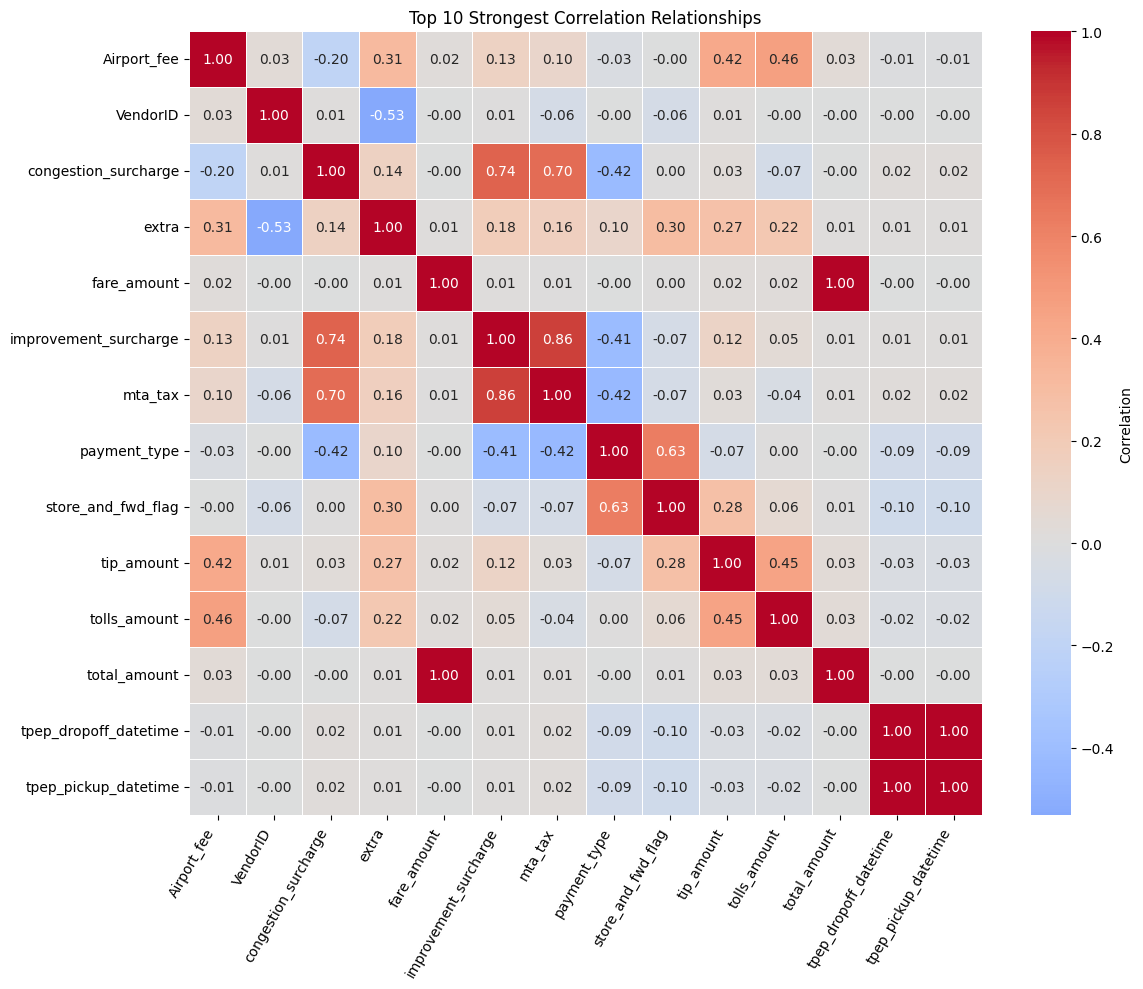

Top 10 strongest correlation pairs:


tpep_pickup_datetime   tpep_dropoff_datetime    0.999995
fare_amount            total_amount             0.999913
mta_tax                improvement_surcharge    0.856520
improvement_surcharge  congestion_surcharge     0.735846
mta_tax                congestion_surcharge     0.697831
store_and_fwd_flag     payment_type             0.628854
VendorID               extra                   -0.532195
tolls_amount           Airport_fee              0.464377
tip_amount             tolls_amount             0.447300
payment_type           mta_tax                 -0.424528
Name: correlation, dtype: float64

In [33]:
# Top 10 strongest correlations (absolute value, excluding self-correlation)
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Recompute a safe correlation matrix in case this cell is run independently
top_corr_df = df.copy()

for col in top_corr_df.select_dtypes(include=["datetime64[ns]", "datetime64[ns, UTC]"]).columns:
    top_corr_df[col] = top_corr_df[col].astype("int64") / 1e9

for col in top_corr_df.columns:
    if not pd.api.types.is_numeric_dtype(top_corr_df[col]):
        top_corr_df[col] = top_corr_df[col].astype("category").cat.codes

top_corr_df = top_corr_df.replace([np.inf, -np.inf], np.nan).dropna(how="all")
top_corr_matrix = top_corr_df.corr(numeric_only=True)

# Extract pairwise correlations from the upper triangle
upper = top_corr_matrix.where(np.triu(np.ones(top_corr_matrix.shape), k=1).astype(bool))
top_pairs = upper.stack().sort_values(key=lambda s: s.abs(), ascending=False).head(10)

if top_pairs.empty:
    print("No correlations available to display.")
else:
    top_cols = sorted(set([a for a, _ in top_pairs.index] + [b for _, b in top_pairs.index]))
    top10_matrix = top_corr_matrix.loc[top_cols, top_cols]

    plt.figure(figsize=(12, 10))
    sns.heatmap(
        top10_matrix,
        annot=True,
        fmt=".2f",
        cmap="coolwarm",
        center=0,
        linewidths=0.4,
        cbar_kws={"label": "Correlation"},
    )
    plt.title("Top 10 Strongest Correlation Relationships")
    plt.xticks(rotation=60, ha="right")
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

    print("Top 10 strongest correlation pairs:")
    display(top_pairs.rename("correlation"))

### What data quality issues would you expect to find, and how might you detect them?

Some issues could include trips with a distance greater than 0 but a passenger count of 0. A possible reason is that the number of passengers was not documented correctly.

Negative values could indicate refunds or partial corrections. Also, the total ride cost could be higher or lower than expected due to recording or billing issues.

There are some instances where the dropoff time is earlier than the pickup time. This is likely a data entry or system error, and those timestamps may need correction.

There are also rides with 0 distance. This could happen if a rider requested a trip but did not ride, if a trip was canceled, or if the distance was not recorded correctly.

Some records show very long trips over 6 hours. These are likely outliers, since both fare and distance are much higher than typical trips.

The columns `trip_distance`, `passenger_count`, `fare_amount`, `total_amount`, and `tip_amount` all contain outliers. `fare_amount` and `total_amount` appear to have the most extreme values, including amounts close to 800,000, which are likely data errors rather than realistic trips.

### Which columns are most likely to be useful for predicting hourly taxi demand by pickup zone, and why

I think the columns most important for predicting hourly taxi demand by pickup zone are **pickup datetime**, **PULocationID**, and **passenger_count**.

Pickup datetime and PULocationID are the most important because our main goal is to estimate taxi demand per location per hour. Without these columns, it would be impossible to complete that goal using the data we were given.

Passenger count could also be useful, because some locations may have fewer rides but higher passenger counts. This could suggest that demand is concentrated in larger-group trips in certain zones. However, passenger count is not strictly necessary to estimate demand at the hourly pickup-zone level.

## AI Assistance and Next Steps

I used an AI coding assistant to help generate and refine code for the exploratory data checks, visualizations, and written explanations in this notebook. I reviewed and edited the results to make sure they matched the assignment goals and the data context.

### Next Steps

- Create time-based features such as hour, day of week, and weekend flag.
- Aggregate rides by `PULocationID` and hour to define the prediction target more clearly.
- Check whether demand patterns vary by location, time of day, and day of week before Week 2's structured EDA.